# 📈 Forecast Diario: ARIMA + EGARCH + Diagnósticos
### Mariann Antonelli Morales Tobias | A01452078
**Econometría Financiera — Proyecto Final**

Este notebook implementa un modelo completo de pronóstico para series de tiempo financieras:
- Descarga automática de datos vía Yahoo Finance
- Análisis de estacionariedad (ADF + KPSS)
- Selección automática ARIMA con `auto_arima`
- Diagnóstico completo de residuos (Ljung-Box, Jarque-Bera, ARCH test)
- Comparación GARCH(1,1) vs EGARCH(1,1)
- Evaluación del modelo con métricas (RMSE, MAE, MAPE) via train/test split
- Gráficos ACF/PACF, distribución de residuos y QQ-plot
- Forecast con intervalos de confianza al 95%
- Señal de inversión combinada (ARIMA + RSI + Medias Móviles)
- Exportación automática a PDF

In [172]:
# ============================================================
# INSTALACIÓN DE LIBRERÍAS
# ============================================================
!pip install pmdarima arch plotly yfinance kaleido scipy -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.backends.backend_pdf as pdf_backend
import plotly.graph_objects as go
import yfinance as yf
import scipy.stats as stats
from pmdarima import auto_arima
from arch import arch_model
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from google.colab import files
import warnings
warnings.filterwarnings('ignore')

print("✅ Librerías cargadas correctamente")

✅ Librerías cargadas correctamente


## 1. Configuración y descarga de datos

In [173]:
# ============================================================
# CONFIGURACIÓN — escribe cualquier ticker de Yahoo Finance
# ============================================================

TICKER = input("Ticker (ej: CMI, NVDA, AAPL): ").strip().upper()

print("\n¿Qué timeframe quieres analizar?")
print("  1 → Diario  (1d)  — últimos 2 años,  forecast 15 días")
print("  2 → Semanal (1wk) — últimos 5 años,  forecast 15 semanas")
print("  3 → Mensual (1mo) — últimos 10 años, forecast 12 meses")
opcion = input("Elige 1, 2 o 3: ").strip()

timeframe_map = {
    '1': ('1d',  'Diario',   '2y',  15, 'B'),
    '2': ('1wk', 'Semanal',  '5y',  15, 'W-FRI'),
    '3': ('1mo', 'Mensual',  '10y', 12, 'MS'),
}
if opcion not in timeframe_map:
    opcion = '1'

interval, label, period, N_PERIODOS, freq_forecast = timeframe_map[opcion]

print(f"\n📌 Configuración:")
print(f"   Ticker    : {TICKER}")
print(f"   Timeframe : {label} ({interval})")
print(f"   Período   : últimos {period}")
print(f"   Forecast  : {N_PERIODOS} períodos hacia adelante")

Ticker (ej: CMI, NVDA, AAPL): XOM

¿Qué timeframe quieres analizar?
  1 → Diario  (1d)  — últimos 2 años,  forecast 15 días
  2 → Semanal (1wk) — últimos 5 años,  forecast 15 semanas
  3 → Mensual (1mo) — últimos 10 años, forecast 12 meses
Elige 1, 2 o 3: 1

📌 Configuración:
   Ticker    : XOM
   Timeframe : Diario (1d)
   Período   : últimos 2y
   Forecast  : 15 períodos hacia adelante


In [174]:
# ============================================================
# DESCARGA DE DATOS — Yahoo Finance
# ============================================================

print(f"\nDescargando datos de {TICKER} desde Yahoo Finance...")

df_raw = yf.download(tickers=TICKER, period=period, interval=interval, progress=False)

if df_raw.empty:
    raise ValueError(f"No se encontraron datos para {TICKER}. Verifica el ticker.")

if isinstance(df_raw.columns, pd.MultiIndex):
    df_raw.columns = df_raw.columns.droplevel(1)

df = df_raw[['Open','High','Low','Close','Volume']].copy().dropna()
df.index = pd.to_datetime(df.index)

print(f"✅ Datos descargados: {len(df)} observaciones")
print(f"   Desde : {df.index[0].date()}")
print(f"   Hasta : {df.index[-1].date()}")
print(f"\nEstadísticas del precio de cierre:")
print(df['Close'].describe().round(2))


Descargando datos de XOM desde Yahoo Finance...
✅ Datos descargados: 501 observaciones
   Desde : 2024-03-14
   Hasta : 2026-03-13

Estadísticas del precio de cierre:
count    501.00
mean     112.29
std       11.09
min       96.61
25%      105.82
50%      110.16
75%      113.90
max      156.12
Name: Close, dtype: float64


## 2. Indicadores técnicos y gráfico interactivo

In [175]:
# ============================================================
# INDICADORES TÉCNICOS
# ============================================================

def calc_rsi(series, period=14):
    delta = series.diff()
    gain  = delta.clip(lower=0).rolling(period).mean()
    loss  = (-delta.clip(upper=0)).rolling(period).mean()
    rs    = gain / loss
    return 100 - (100 / (1 + rs))

def calc_bollinger(series, window=20):
    ma  = series.rolling(window).mean()
    std = series.rolling(window).std()
    return ma, ma + 2*std, ma - 2*std

df['RSI']    = calc_rsi(df['Close'])
df['MA20']   = df['Close'].rolling(20).mean()
df['MA50']   = df['Close'].rolling(50).mean()
df['BB_mid'], df['BB_up'], df['BB_low'] = calc_bollinger(df['Close'])

# Retorno logarítmico diario (para análisis)
df['log_ret'] = np.log(df['Close']).diff() * 100

print("✅ Indicadores calculados: RSI(14), MA20, MA50, Bandas Bollinger(20)")

✅ Indicadores calculados: RSI(14), MA20, MA50, Bandas Bollinger(20)


In [176]:
# ============================================================
# GRÁFICO CANDLESTICK INTERACTIVO (Plotly)
# ============================================================

ultimos = min(180, len(df))
df_plot = df.iloc[-ultimos:]

fig = go.Figure()
fig.add_trace(go.Candlestick(
    x=df_plot.index, open=df_plot['Open'], high=df_plot['High'],
    low=df_plot['Low'], close=df_plot['Close'], name=TICKER, yaxis='y1'))
fig.add_trace(go.Scatter(
    x=df_plot.index, y=df_plot['BB_up'],
    line=dict(color='rgba(255,165,0,0.4)', width=1), name='BB Superior', yaxis='y1'))
fig.add_trace(go.Scatter(
    x=df_plot.index, y=df_plot['BB_low'],
    line=dict(color='rgba(255,165,0,0.4)', width=1),
    fill='tonexty', fillcolor='rgba(255,165,0,0.05)', name='BB Inferior', yaxis='y1'))
fig.add_trace(go.Scatter(
    x=df_plot.index, y=df_plot['MA20'],
    line=dict(color='cyan', width=1.5), name='MA20', yaxis='y1'))
fig.add_trace(go.Scatter(
    x=df_plot.index, y=df_plot['MA50'],
    line=dict(color='magenta', width=1.5), name='MA50', yaxis='y1'))
fig.add_trace(go.Bar(
    x=df_plot.index, y=df_plot['Volume'],
    name='Volumen', marker_color='rgba(100,100,255,0.4)', yaxis='y2'))
fig.add_trace(go.Scatter(
    x=df_plot.index, y=df_plot['RSI'],
    line=dict(color='yellow', width=1), name='RSI(14)', yaxis='y3'))
fig.add_hline(y=70, line_dash='dash', line_color='red',   annotation_text='Sobrecompra', yref='y3')
fig.add_hline(y=30, line_dash='dash', line_color='green', annotation_text='Sobreventa',  yref='y3')

fig.update_layout(
    title=f'{TICKER} — {label} | MA20, MA50, Bollinger, RSI(14)',
    template='plotly_dark', xaxis_rangeslider_visible=False,
    yaxis  = dict(domain=[0.45, 1.0], title='Precio ($)'),
    yaxis2 = dict(domain=[0.25, 0.43], title='Volumen'),
    yaxis3 = dict(domain=[0.00, 0.23], title='RSI', range=[0,100]),
    height=800)
fig.show()

## 3. Análisis de estacionariedad

In [177]:
# ============================================================
# PRUEBAS ADF Y KPSS
# ============================================================

def test_estacionariedad(series, nombre):
    print(f"\n{'='*55}")
    print(f"  PRUEBAS DE ESTACIONARIEDAD — {nombre}")
    print(f"{'='*55}")

    # ADF
    adf = adfuller(series.dropna())
    print(f"\n📊 ADF (Augmented Dickey-Fuller):")
    print(f"   Estadístico : {adf[0]:.4f}")
    print(f"   p-value     : {adf[1]:.4f}")
    print(f"   Valores críticos: 1%={adf[4]['1%']:.3f}, 5%={adf[4]['5%']:.3f}, 10%={adf[4]['10%']:.3f}")
    print(f"   → {'✅ Estacionaria (rechaza raíz unitaria)' if adf[1] < 0.05 else '❌ No estacionaria (no rechaza raíz unitaria)'}")

    # KPSS
    kpss_r = kpss(series.dropna(), regression='c', nlags='auto')
    print(f"\n📊 KPSS (Kwiatkowski-Phillips-Schmidt-Shin):")
    print(f"   Estadístico : {kpss_r[0]:.4f}")
    print(f"   p-value     : {kpss_r[1]:.4f}")
    print(f"   → {'✅ Estacionaria (no rechaza estacionariedad)' if kpss_r[1] > 0.05 else '❌ No estacionaria (rechaza estacionariedad)'}")

    return adf[1], kpss_r[1]

# Precio en niveles
adf_p, kpss_p = test_estacionariedad(df['Close'], f'{TICKER} — Precio de Cierre')

# Retornos logarítmicos
serie = df['log_ret'].dropna()
adf_r, kpss_r = test_estacionariedad(serie, f'{TICKER} — Retornos Logarítmicos (%)')

print("\n→ Modelando retornos logarítmicos (%) para garantizar estacionariedad")


  PRUEBAS DE ESTACIONARIEDAD — XOM — Precio de Cierre

📊 ADF (Augmented Dickey-Fuller):
   Estadístico : 0.7087
   p-value     : 0.9900
   Valores críticos: 1%=-3.443, 5%=-2.867, 10%=-2.570
   → ❌ No estacionaria (no rechaza raíz unitaria)

📊 KPSS (Kwiatkowski-Phillips-Schmidt-Shin):
   Estadístico : 1.3007
   p-value     : 0.0100
   → ❌ No estacionaria (rechaza estacionariedad)

  PRUEBAS DE ESTACIONARIEDAD — XOM — Retornos Logarítmicos (%)

📊 ADF (Augmented Dickey-Fuller):
   Estadístico : -22.3655
   p-value     : 0.0000
   Valores críticos: 1%=-3.444, 5%=-2.867, 10%=-2.570
   → ✅ Estacionaria (rechaza raíz unitaria)

📊 KPSS (Kwiatkowski-Phillips-Schmidt-Shin):
   Estadístico : 0.2856
   p-value     : 0.1000
   → ✅ Estacionaria (no rechaza estacionariedad)

→ Modelando retornos logarítmicos (%) para garantizar estacionariedad


## 4. Gráficos ACF y PACF

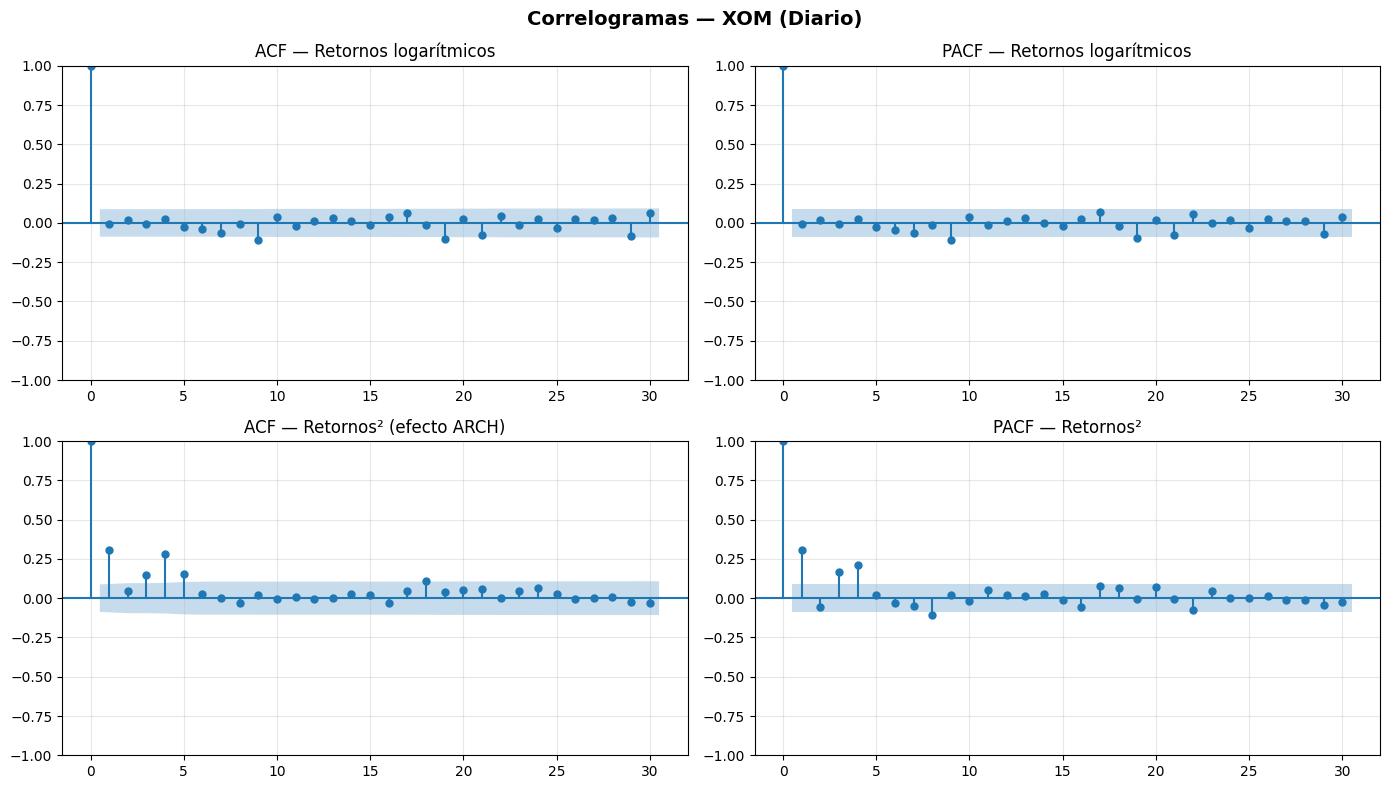

📌 Interpretación:
   ACF/PACF de retornos     → identifica orden AR y MA para ARIMA
   ACF/PACF de retornos²   → correlaciones en varianza, justifica modelo GARCH


In [178]:
# ============================================================
# ACF Y PACF — Retornos y Retornos al Cuadrado
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle(f'Correlogramas — {TICKER} ({label})', fontsize=14, fontweight='bold')

plot_acf(serie,         ax=axes[0,0], lags=30, title='ACF — Retornos logarítmicos')
plot_pacf(serie,        ax=axes[0,1], lags=30, title='PACF — Retornos logarítmicos')
plot_acf(serie**2,      ax=axes[1,0], lags=30, title='ACF — Retornos² (efecto ARCH)')
plot_pacf(serie**2,     ax=axes[1,1], lags=30, title='PACF — Retornos²')

for ax in axes.flatten():
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("📌 Interpretación:")
print("   ACF/PACF de retornos     → identifica orden AR y MA para ARIMA")
print("   ACF/PACF de retornos²   → correlaciones en varianza, justifica modelo GARCH")

## 5. Ajuste ARIMA y diagnóstico de residuos

In [179]:
# ============================================================
# TRAIN / TEST SPLIT — 80% entrenamiento, 20% prueba
# ============================================================

n_total = len(serie)
n_train = int(n_total * 0.80)
n_test  = n_total - n_train

serie_train = serie.iloc[:n_train]
serie_test  = serie.iloc[n_train:]

print(f"División Train/Test:")
print(f"   Total       : {n_total} observaciones")
print(f"   Entrenamiento (80%) : {n_train} obs — hasta {serie_train.index[-1].date()}")
print(f"   Prueba (20%)        : {n_test}  obs — desde {serie_test.index[0].date()}")

División Train/Test:
   Total       : 500 observaciones
   Entrenamiento (80%) : 400 obs — hasta 2025-10-17
   Prueba (20%)        : 100  obs — desde 2025-10-20


In [180]:
# ============================================================
# AJUSTE ARIMA CON AUTO_ARIMA + protección contra modelo inadecuado
# ============================================================

print(f"\nAjustando ARIMA sobre datos de entrenamiento ({n_train} obs)...")
print("   Puede tomar 1-2 minutos...\n")

from pmdarima import auto_arima, ARIMA as pmdARIMA

arima_fit = auto_arima(
    serie_train,
    seasonal=False,
    stepwise=True,
    max_p=5,
    max_q=5,
    max_d=2,                    # permite hasta segunda diferencia si es necesario
    d=None,                     # ← que auto_arima lo decida (importante)
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    information_criterion='aic'  # o 'bic' si prefieres ser más conservador
)

# Importante: auto_arima YA ajusta el modelo → NO necesitas .fit() después
# arima_fit.fit(serie_train)   ← ESTO SOBRA, elimínalo

print("\n" + "="*60)
print("Mejor modelo encontrado por auto_arima:", arima_fit.order)
print("Resumen del modelo:")
print(arima_fit.summary())

# ------------------------------------------------------------
# Protección contra modelos inadecuados para series de precios
# ------------------------------------------------------------
if arima_fit.order[1] == 0:   # si NO hay diferenciación (d=0)
    print("\n⚠️  ADVERTENCIA: auto_arima eligió d=0 (sin diferenciación)")
    print("   Esto suele producir forecast plano en series de precios")
    print("   → Forzando modelo con primera diferencia: ARIMA(1,1,1)\n")

    arima_fit = pmdARIMA(
        order=(1, 1, 1),
        suppress_warnings=True
    )
    arima_fit.fit(serie_train)

elif arima_fit.order == (0, 0, 0):
    print("\n⚠️  auto_arima seleccionó (0,0,0) — forzando ARIMA(1,1,1)")
    arima_fit = pmdARIMA(
        order=(1, 1, 1),
        suppress_warnings=True
    )
    arima_fit.fit(serie_train)

# ------------------------------------------------------------
# Resultado final (siempre se muestra)
# ------------------------------------------------------------
print("\n" + "="*60)
print(f"✅ Orden ARIMA **final** utilizado: {arima_fit.order}")
print(f"   AIC : {arima_fit.aic():.4f}")
print(f"   BIC : {arima_fit.bic():.4f}")
print("\nResumen del modelo final:")
print(arima_fit.summary())

print("\nDEBUG: orden que se va a usar para predecir →", arima_fit.order)

# Muestra las primeras predicciones crudas (deben tener tendencia si d=1)
fc_debug = arima_fit.predict(n_periods=5)
print("Primeras 5 predicciones crudas (deben cambiar si hay diferencia):")
print(fc_debug)


Ajustando ARIMA sobre datos de entrenamiento (400 obs)...
   Puede tomar 1-2 minutos...

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=1409.727, Time=0.68 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=1404.963, Time=0.04 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=1406.861, Time=0.07 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=1406.873, Time=0.16 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=1404.508, Time=0.58 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=1405.497, Time=0.96 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=1408.350, Time=0.41 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=1406.794, Time=0.37 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=1406.955, Time=0.15 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=1406.463, Time=0.79 sec

Best model:  ARIMA(1,0,1)(0,0,0)[0]          
Total fit time: 4.232 seconds

Mejor modelo encontrado por auto_arima: (1, 0, 1)
Resumen del modelo:
                               SARIMAX Results             

In [181]:
# ============================================================
# DIAGNÓSTICO DE RESIDUOS
# ============================================================

residuos = np.array(arima_fit.resid())
residuos = residuos[~np.isnan(residuos)]

print(f"\n{'='*55}")
print(f"  DIAGNÓSTICO DE RESIDUOS — {TICKER}")
print(f"{'='*55}")

# --- Ljung-Box ---
lb = acorr_ljungbox(residuos, lags=[5, 10, 15], return_df=True)
print("\n📊 Prueba Ljung-Box (H₀: no hay autocorrelación en residuos):")
print(lb.to_string())
lb_p = lb['lb_pvalue'].min()
print(f"   → {'✅ Residuos sin autocorrelación (p > 0.05)' if lb_p > 0.05 else '⚠️  Autocorrelación detectada (p ≤ 0.05)'}")

# --- Jarque-Bera ---
jb_stat, jb_p = stats.jarque_bera(residuos)
print(f"\n📊 Prueba Jarque-Bera (H₀: residuos normales):")
print(f"   Estadístico : {jb_stat:.4f}")
print(f"   p-value     : {jb_p:.4f}")
print(f"   → {'✅ Residuos normales' if jb_p > 0.05 else '⚠️  Residuos no normales (común en finanzas)'}")

# --- ARCH test (Ljung-Box sobre residuos²) ---
lb_arch = acorr_ljungbox(residuos**2, lags=[5, 10], return_df=True)
print("\n📊 ARCH Test — Ljung-Box sobre residuos² (H₀: no hay efectos ARCH):")
print(lb_arch.to_string())
arch_p = lb_arch['lb_pvalue'].min()
print(f"   → {'✅ Sin efectos ARCH' if arch_p > 0.05 else '✅ Efectos ARCH detectados → GARCH justificado'}")


  DIAGNÓSTICO DE RESIDUOS — XOM

📊 Prueba Ljung-Box (H₀: no hay autocorrelación en residuos):
      lb_stat  lb_pvalue
5    2.980515   0.702990
10  15.248330   0.123267
15  16.076900   0.376959
   → ✅ Residuos sin autocorrelación (p > 0.05)

📊 Prueba Jarque-Bera (H₀: residuos normales):
   Estadístico : 145.0756
   p-value     : 0.0000
   → ⚠️  Residuos no normales (común en finanzas)

📊 ARCH Test — Ljung-Box sobre residuos² (H₀: no hay efectos ARCH):
      lb_stat     lb_pvalue
5   98.288255  1.212648e-19
10  99.208960  7.845783e-17
   → ✅ Efectos ARCH detectados → GARCH justificado


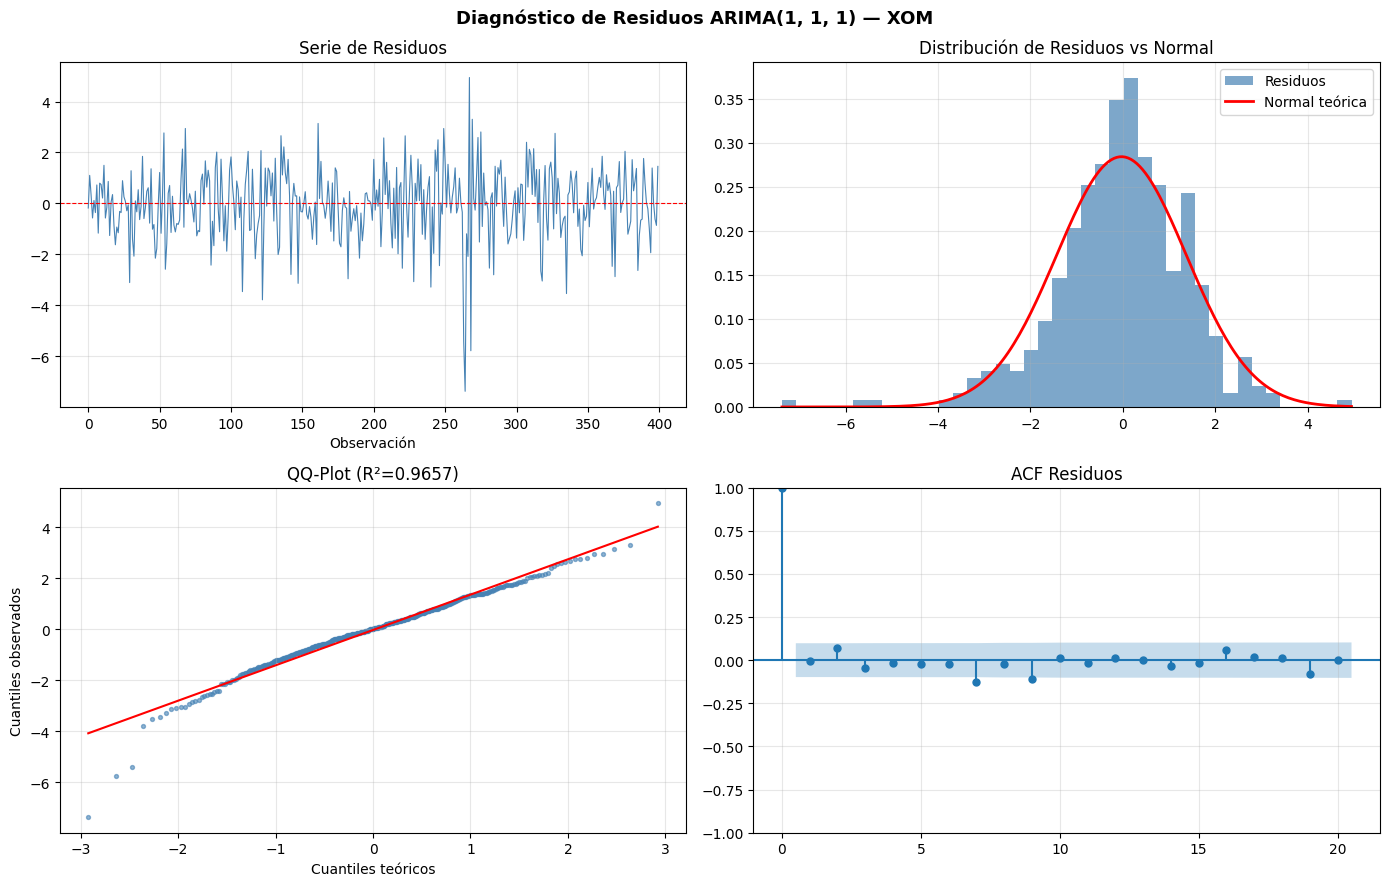

In [182]:
# ============================================================
# GRÁFICOS DE DIAGNÓSTICO DE RESIDUOS
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle(f'Diagnóstico de Residuos ARIMA{arima_fit.order} — {TICKER}',
             fontsize=13, fontweight='bold')

# 1) Serie de residuos
axes[0,0].plot(residuos, color='steelblue', linewidth=0.8)
axes[0,0].axhline(0, color='red', linestyle='--', linewidth=0.8)
axes[0,0].set_title('Serie de Residuos')
axes[0,0].set_xlabel('Observación')
axes[0,0].grid(True, alpha=0.3)

# 2) Histograma + curva normal
axes[0,1].hist(residuos, bins=40, density=True, color='steelblue',
               alpha=0.7, label='Residuos')
xr = np.linspace(residuos.min(), residuos.max(), 200)
axes[0,1].plot(xr, stats.norm.pdf(xr, residuos.mean(), residuos.std()),
               'r-', linewidth=2, label='Normal teórica')
axes[0,1].set_title('Distribución de Residuos vs Normal')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# 3) QQ-Plot
(osm, osr), (slope, intercept, r) = stats.probplot(residuos)
axes[1,0].scatter(osm, osr, s=8, color='steelblue', alpha=0.6)
axes[1,0].plot(osm, slope*np.array(osm)+intercept, 'r-', linewidth=1.5)
axes[1,0].set_title(f'QQ-Plot (R²={r**2:.4f})')
axes[1,0].set_xlabel('Cuantiles teóricos')
axes[1,0].set_ylabel('Cuantiles observados')
axes[1,0].grid(True, alpha=0.3)

# 4) ACF residuos
plot_acf(residuos, ax=axes[1,1], lags=20, title='ACF Residuos')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Modelado de volatilidad: GARCH vs EGARCH

In [183]:
# ============================================================
# GARCH(1,1)
# ============================================================

print("Ajustando GARCH(1,1)...")
garch_model  = arch_model(residuos, mean='Zero', vol='Garch', p=1, q=1, dist='Normal')
garch_fit    = garch_model.fit(disp='off', show_warning=False)
vol_garch    = np.array(garch_fit.conditional_volatility)

print(garch_fit.summary())
print(f"\n   AIC GARCH(1,1) : {garch_fit.aic:.4f}")
print(f"   BIC GARCH(1,1) : {garch_fit.bic:.4f}")

Ajustando GARCH(1,1)...
                       Zero Mean - GARCH Model Results                        
Dep. Variable:                      y   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.002
Vol Model:                      GARCH   Log-Likelihood:               -689.123
Distribution:                  Normal   AIC:                           1384.25
Method:            Maximum Likelihood   BIC:                           1396.22
                                        No. Observations:                  400
Date:                Sun, Mar 15 2026   Df Residuals:                      400
Time:                        02:34:24   Df Model:                            0
                              Volatility Model                             
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
omega          0.4256      0.628     

In [184]:
# ============================================================
# EGARCH(1,1) — captura asimetría de volatilidad
# ============================================================

print("Ajustando EGARCH(1,1)...")
try:
    egarch_m   = arch_model(residuos, mean='Zero', vol='EGARCH', p=1, q=1, dist='Normal')
    egarch_fit = egarch_m.fit(disp='off', show_warning=False)
    vol_egarch = np.array(egarch_fit.conditional_volatility)
    aic_egarch = egarch_fit.aic
except:
    print("⚠️ EGARCH no convergió — usando GARCH(1,1) como único modelo")
    egarch_fit = garch_fit
    vol_egarch = vol_garch
    aic_egarch = garch_fit.aic + 1  # forzar que GARCH gane

# Selección de modelo
mejor_vol_model = 'GARCH' if garch_fit.aic <= egarch_fit.aic else 'EGARCH'
mejor_vol_fit   = garch_fit if mejor_vol_model == 'GARCH' else egarch_fit
mejor_vol       = vol_garch  if mejor_vol_model == 'GARCH' else vol_egarch

print(f"\n{'='*45}")
print(f"  Comparación de modelos de volatilidad")
print(f"{'='*45}")
print(f"  GARCH(1,1)  — AIC: {garch_fit.aic:.4f}  BIC: {garch_fit.bic:.4f}")
print(f"  EGARCH(1,1) — AIC: {egarch_fit.aic:.4f}  BIC: {egarch_fit.bic:.4f}")
print(f"  ✅ Mejor modelo (menor AIC): {mejor_vol_model}(1,1)")

Ajustando EGARCH(1,1)...

  Comparación de modelos de volatilidad
  GARCH(1,1)  — AIC: 1384.2455  BIC: 1396.2199
  EGARCH(1,1) — AIC: 1390.8820  BIC: 1402.8564
  ✅ Mejor modelo (menor AIC): GARCH(1,1)


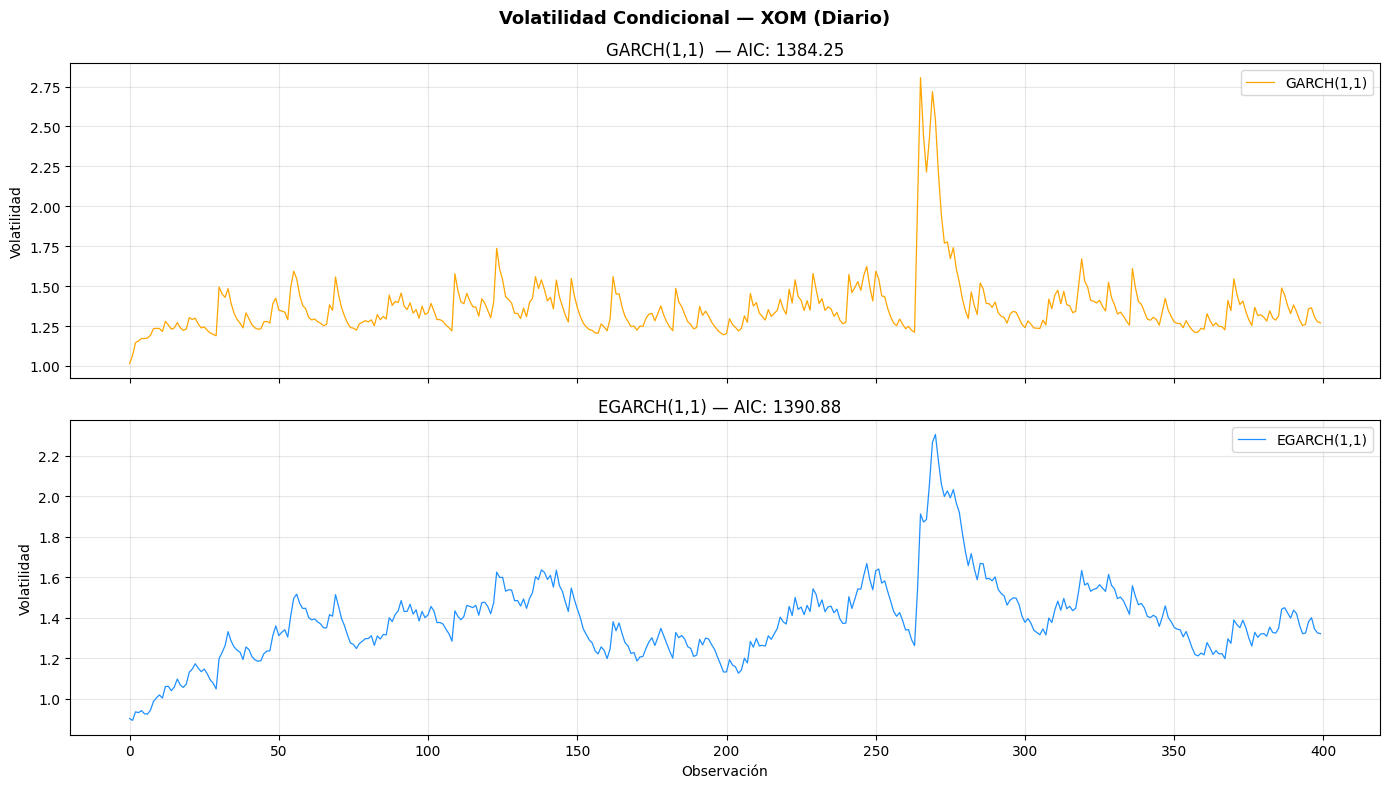


✅ Volatilidad actual (GARCH): 1.2698


In [185]:
# ============================================================
# GRÁFICO COMPARATIVO GARCH vs EGARCH
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle(f'Volatilidad Condicional — {TICKER} ({label})', fontsize=13, fontweight='bold')

axes[0].plot(vol_garch,  color='orange', linewidth=0.9, label='GARCH(1,1)')
axes[0].set_title(f'GARCH(1,1)  — AIC: {garch_fit.aic:.2f}')
axes[0].set_ylabel('Volatilidad')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(vol_egarch, color='dodgerblue', linewidth=0.9, label='EGARCH(1,1)')
axes[1].set_title(f'EGARCH(1,1) — AIC: {egarch_fit.aic:.2f}  {"← Mejor modelo ✅" if mejor_vol_model=="EGARCH" else ""}')
axes[1].set_ylabel('Volatilidad')
axes[1].set_xlabel('Observación')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

vol_pred = float(mejor_vol[-1])
print(f"\n✅ Volatilidad actual ({mejor_vol_model}): {vol_pred:.4f}")

## 7. Evaluación del modelo: métricas RMSE, MAE y MAPE

Generando predicciones sobre el conjunto de prueba (100 obs)...

  MÉTRICAS DE EVALUACIÓN — XOM (Diario)
  RMSE (Root Mean Squared Error) : 1.514393
  MAE  (Mean Absolute Error)     : 1.219350
  MAPE (Mean Abs. Pct. Error)    : 67916.8080%

Interpretación:
   RMSE=1.5144 — error cuadrático medio en unidades de retorno (%)
   MAE =1.2193  — error absoluto promedio por período
   MAPE=67916.81% — porcentaje de error promedio en la dirección


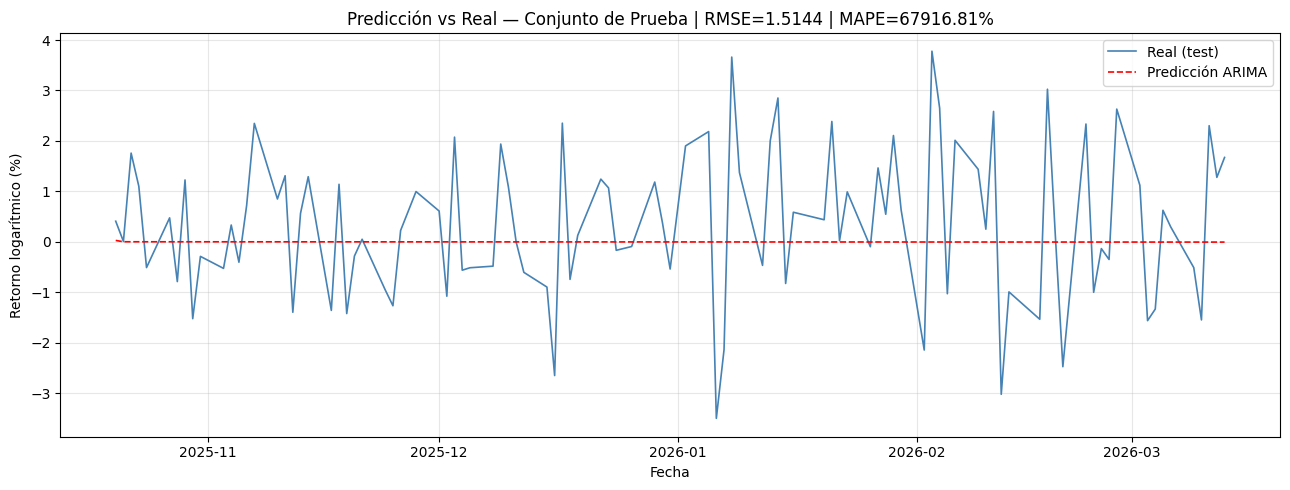

In [186]:
# ============================================================
# EVALUACIÓN IN-SAMPLE: TRAIN/TEST SPLIT
# ============================================================

print(f"Generando predicciones sobre el conjunto de prueba ({n_test} obs)...")

# Predicciones sobre test
pred_test = arima_fit.predict(n_periods=n_test)
real_test = np.array(serie_test)

# Métricas
rmse = np.sqrt(np.mean((pred_test - real_test)**2))
mae  = np.mean(np.abs(pred_test - real_test))
mape = np.mean(np.abs((pred_test - real_test) / (np.abs(real_test) + 1e-8))) * 100

print(f"\n{'='*50}")
print(f"  MÉTRICAS DE EVALUACIÓN — {TICKER} ({label})")
print(f"{'='*50}")
print(f"  RMSE (Root Mean Squared Error) : {rmse:.6f}")
print(f"  MAE  (Mean Absolute Error)     : {mae:.6f}")
print(f"  MAPE (Mean Abs. Pct. Error)    : {mape:.4f}%")
print(f"{'='*50}")
print("\nInterpretación:")
print(f"   RMSE={rmse:.4f} — error cuadrático medio en unidades de retorno (%)")
print(f"   MAE ={mae:.4f}  — error absoluto promedio por período")
print(f"   MAPE={mape:.2f}% — porcentaje de error promedio en la dirección")

# Gráfico predicción vs real (test)
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(serie_test.index, real_test,  label='Real (test)',      color='steelblue', linewidth=1.2)
ax.plot(serie_test.index, pred_test,  label='Predicción ARIMA', color='red',       linewidth=1.2, linestyle='--')
ax.set_title(f'Predicción vs Real — Conjunto de Prueba | RMSE={rmse:.4f} | MAPE={mape:.2f}%')
ax.set_xlabel('Fecha')
ax.set_ylabel('Retorno logarítmico (%)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Forecast: próximos períodos

In [187]:
# ============================================================
# RE-ENTRENAR CON TODOS LOS DATOS Y GENERAR FORECAST
# ============================================================

from pmdarima.arima import ARIMA

print(f"\nRe-entrenando ARIMA {arima_fit.order} con TODOS los datos (serie completa)...")

# ── Modelo final: usamos directamente ARIMA con el orden ya decidido ──
#    Esto evita que auto_arima vuelva a "olvidar" la diferenciación
arima_final = ARIMA(
    order=arima_fit.order,           # conserva p, d, q que ya forzaste o elegiste
    suppress_warnings=True
)

arima_final.fit(serie)

print(f"   Orden confirmado para forecast: {arima_final.order}")
print(f"   Modelo re-entrenado correctamente.")

# ── Preparación de fechas futuras ──
future_index = pd.date_range(
    start = df.index[-1] + pd.Timedelta(days=1),   # empieza DESPUÉS del último día real
    periods = N_PERIODOS,
    freq = freq_forecast
)

close_arr     = np.array(df['Close'])
precio_actual = float(close_arr[-1])

# ── Predicciones (ahora deberían tener tendencia si d ≥ 1) ──
preds_array = np.array(arima_final.predict(n_periods=N_PERIODOS))

print("\nDEBUG: primeras predicciones crudas de ARIMA (deben variar si hay d≥1):")
print(preds_array[:8])   # ← agrega esto temporalmente para verificar

# ── Reconstrucción de precios (multiplicativa, asumiendo que preds son log-retornos o aproximados) ──
precios_pred  = [precio_actual]
precios_lower = [precio_actual]
precios_upper = [precio_actual]

for i, r in enumerate(preds_array):
    r = float(r)
    ret = r / 100                     # si ARIMA predice en % → convertir a decimal
    # Nota: si ARIMA está modelando precios directamente (no retornos), cambia esta parte
    #       (ver más abajo si es necesario)

    nuevo_precio = precios_pred[-1] * np.exp(ret)

    # Volatilidad para bandas (tu fórmula actual)
    vol_i = vol_pred / 100 * np.sqrt(i + 1)

    precios_pred.append(round(nuevo_precio, 2))
    precios_lower.append(round(nuevo_precio * np.exp(-1.96 * vol_i), 2))
    precios_upper.append(round(nuevo_precio * np.exp( 1.96 * vol_i), 2))

precios_pred  = precios_pred[1:]
precios_lower = precios_lower[1:]
precios_upper = precios_upper[1:]

# ── DataFrame final ──
forecast_df = pd.DataFrame({
    'Fecha'              : future_index.strftime('%Y-%m-%d'),
    'Precio Predicho'    : precios_pred,
    'Lím. Inferior 95%'  : precios_lower,
    'Lím. Superior 95%'  : precios_upper
})

print(f"\n{'='*58}")
print(f"  FORECAST {label.upper()} — {TICKER}")
print(f"{'='*58}")
print(forecast_df.to_string(index=False))


Re-entrenando ARIMA (1, 1, 1) con TODOS los datos (serie completa)...
   Orden confirmado para forecast: (1, 1, 1)
   Modelo re-entrenado correctamente.

DEBUG: primeras predicciones crudas de ARIMA (deben variar si hay d≥1):
[0.22923857 0.23910154 0.23967188 0.24030163 0.24093101 0.24156038
 0.24218975 0.24281913]

  FORECAST DIARIO — XOM
     Fecha  Precio Predicho  Lím. Inferior 95%  Lím. Superior 95%
2026-03-16           156.48             152.63             160.42
2026-03-17           156.85             151.43             162.47
2026-03-18           157.23             150.59             164.15
2026-03-19           157.61             149.96             165.65
2026-03-20           157.99             149.44             167.03
2026-03-23           158.37             149.01             168.33
2026-03-24           158.75             148.64             169.56
2026-03-25           159.14             148.32             170.74
2026-03-26           159.53             148.05             171.

In [188]:
# ============================================================
# SEÑAL DE INVERSIÓN
# ============================================================

precio_max    = float(np.max(precios_pred))
precio_min    = float(np.min(precios_pred))
promedio_pred = float(np.mean(precios_pred))
std_pred      = float(np.std(precios_pred))
upside        = precio_max - precio_actual
downside      = precio_actual - precio_min
umbral        = std_pred * 1.5

rsi_actual  = float(np.array(df['RSI'])[-1])
ma20_actual = float(np.array(df['MA20'])[-1])
ma50_actual = float(np.array(df['MA50'])[-1])

print(f"\n{'='*58}")
print(f"  RESUMEN — {TICKER} ({label})")
print(f"{'='*58}")
print(f"  Precio actual         : ${precio_actual:.2f}")
print(f"  Precio promedio pred. : ${promedio_pred:.2f}")
print(f"  Máximo predicho       : ${precio_max:.2f}  (+${upside:.2f})")
print(f"  Mínimo predicho       : ${precio_min:.2f}  (-${downside:.2f})")
print(f"  Volatilidad {mejor_vol_model}  : {vol_pred:.4f}")
print(f"  RSI(14) actual        : {rsi_actual:.1f}")
print(f"  MA20                  : ${ma20_actual:.2f}")
print(f"  MA50                  : ${ma50_actual:.2f}")
print(f"  Precio vs MA20        : {'📈 Arriba' if precio_actual > ma20_actual else '📉 Abajo'}")
print(f"  Precio vs MA50        : {'📈 Arriba' if precio_actual > ma50_actual else '📉 Abajo'}")
print(f"{'='*58}")
print(f"\n  MÉTRICAS MODELO:")
print(f"  RMSE={rmse:.4f}  |  MAE={mae:.4f}  |  MAPE={mape:.2f}%")
print(f"  ARIMA{arima_fit.order}  |  {mejor_vol_model}(1,1)  |  AIC={arima_final.aic():.2f}")
print(f"{'='*58}")

# Señal
senal_arima = ("🟢 BUY" if upside > umbral else "🟡 HOLD") if upside > downside else               ("🔴 SELL/SHORT" if downside > umbral else "🟡 HOLD")
senal_rsi   = "⚠️ SOBRECOMPRADO" if rsi_actual > 70 else               ("⚠️ SOBREVENDIDO"  if rsi_actual < 30 else "✅ RSI neutral")
senal_ma    = "📈 Tendencia alcista" if precio_actual > ma20_actual > ma50_actual else               ("📉 Tendencia bajista" if precio_actual < ma20_actual < ma50_actual else "↔️ Tendencia mixta")

senal_final = f"{senal_arima}  |  {senal_rsi}  |  {senal_ma}"
print(f"\n  📡 SEÑAL: {senal_final}")
print(f"{'='*58}")


  RESUMEN — XOM (Diario)
  Precio actual         : $156.12
  Precio promedio pred. : $159.16
  Máximo predicho       : $161.90  (+$5.78)
  Mínimo predicho       : $156.48  (-$-0.36)
  Volatilidad GARCH  : 1.2698
  RSI(14) actual        : 60.8
  MA20                  : $150.57
  MA50                  : $140.75
  Precio vs MA20        : 📈 Arriba
  Precio vs MA50        : 📈 Arriba

  MÉTRICAS MODELO:
  RMSE=1.5144  |  MAE=1.2193  |  MAPE=67916.81%
  ARIMA(1, 1, 1)  |  GARCH(1,1)  |  AIC=1778.71

  📡 SEÑAL: 🟢 BUY  |  ✅ RSI neutral  |  📈 Tendencia alcista


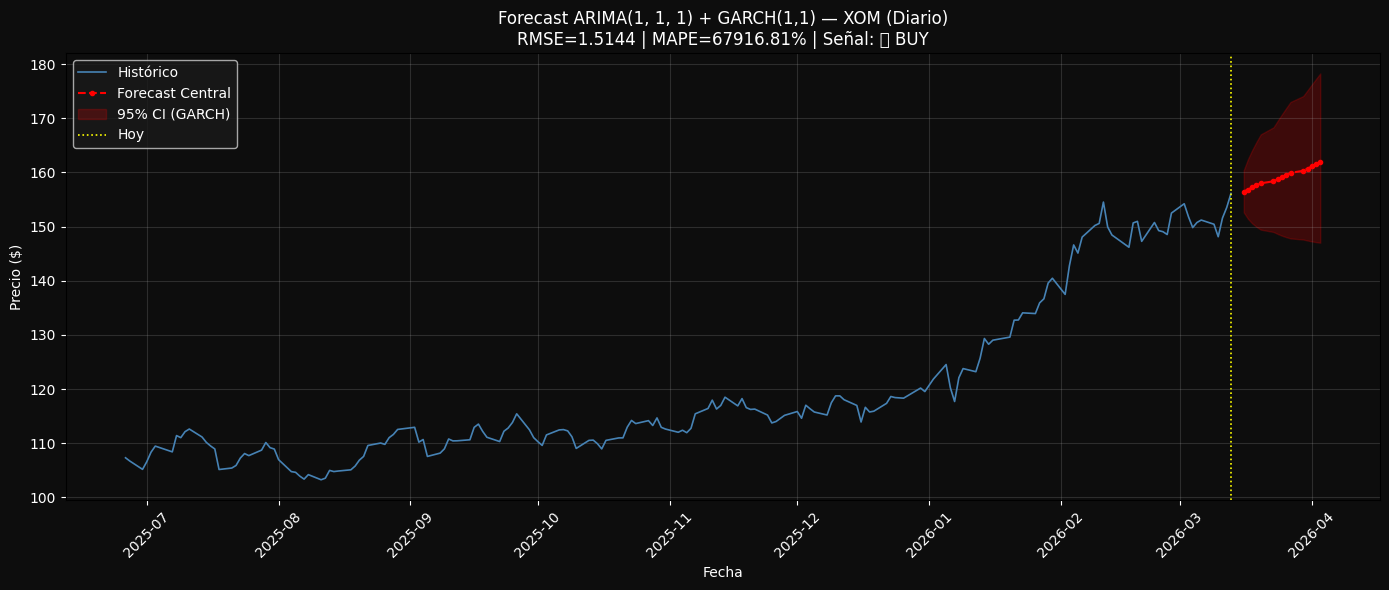

In [189]:
# ============================================================
# GRÁFICO FORECAST FINAL
# ============================================================

ultimos_plot = min(180, len(df))
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df.index[-ultimos_plot:], df['Close'][-ultimos_plot:],
        label='Histórico', color='steelblue', linewidth=1.2)
ax.plot(future_index, precios_pred,
        label='Forecast Central', color='red', marker='o', markersize=3, linestyle='--')
ax.fill_between(future_index, precios_lower, precios_upper,
                color='red', alpha=0.2, label=f'95% CI ({mejor_vol_model})')
ax.axvline(x=df.index[-1], color='yellow', linestyle=':', linewidth=1.2, label='Hoy')
ax.set_title(f'Forecast ARIMA{arima_fit.order} + {mejor_vol_model}(1,1) — {TICKER} ({label})\n'
             f'RMSE={rmse:.4f} | MAPE={mape:.2f}% | Señal: {senal_arima}')
ax.set_xlabel('Fecha')
ax.set_ylabel('Precio ($)')
ax.legend(facecolor='#1a1a1a', labelcolor='white')
ax.grid(True, alpha=0.2)
ax.set_facecolor('#0d0d0d')
fig.set_facecolor('#0d0d0d')
ax.tick_params(colors='white')
ax.title.set_color('white')
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 9. Exportación a PDF

In [190]:
# ============================================================
# GENERACIÓN DE PDF — 5 páginas
# ============================================================

pdf_path = f"Forecast_{label}_{TICKER}_MAMT.pdf"
print(f"Generando PDF: {pdf_path}...")

with pdf_backend.PdfPages(pdf_path) as pdf_pages:

    # --- Pág 1: Chart con indicadores ---
    fig1 = plt.figure(figsize=(14, 10))
    gs   = gridspec.GridSpec(3, 1, height_ratios=[3, 1, 1])
    ax1  = fig1.add_subplot(gs[0])
    ax1.plot(df.index[-ultimos_plot:], df['Close'][-ultimos_plot:], color='white', linewidth=1, label='Close')
    ax1.plot(df.index[-ultimos_plot:], df['MA20'][-ultimos_plot:],  color='cyan',    linewidth=1.2, label='MA20')
    ax1.plot(df.index[-ultimos_plot:], df['MA50'][-ultimos_plot:],  color='magenta', linewidth=1.2, label='MA50')
    ax1.plot(df.index[-ultimos_plot:], df['BB_up'][-ultimos_plot:], color='orange',  linewidth=0.8, linestyle='--', label='BB')
    ax1.plot(df.index[-ultimos_plot:], df['BB_low'][-ultimos_plot:],color='orange',  linewidth=0.8, linestyle='--')
    ax1.fill_between(df.index[-ultimos_plot:], df['BB_up'][-ultimos_plot:], df['BB_low'][-ultimos_plot:], alpha=0.05, color='orange')
    ax1.set_title(f'{TICKER} — {label} | MA20, MA50, BB, RSI(14)', color='white')
    ax1.set_facecolor('#0d0d0d'); ax1.tick_params(colors='white')
    ax1.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=8)
    ax1.grid(True, alpha=0.2)
    ax_v = fig1.add_subplot(gs[1], sharex=ax1)
    ax_v.bar(df.index[-ultimos_plot:], df['Volume'][-ultimos_plot:], color='steelblue', alpha=0.5)
    ax_v.set_ylabel('Volumen', color='white'); ax_v.set_facecolor('#0d0d0d'); ax_v.tick_params(colors='white')
    ax_r = fig1.add_subplot(gs[2], sharex=ax1)
    ax_r.plot(df.index[-ultimos_plot:], df['RSI'][-ultimos_plot:], color='yellow', linewidth=1)
    ax_r.axhline(70, color='red', linestyle='--', linewidth=0.8)
    ax_r.axhline(30, color='green', linestyle='--', linewidth=0.8)
    ax_r.set_ylim(0, 100); ax_r.set_ylabel('RSI(14)', color='white')
    ax_r.set_facecolor('#0d0d0d'); ax_r.tick_params(colors='white')
    fig1.patch.set_facecolor('#0d0d0d')
    plt.xticks(rotation=45); plt.tight_layout()
    pdf_pages.savefig(fig1, bbox_inches='tight'); plt.close(fig1)

    # --- Pág 2: Diagnóstico residuos ---
    fig2, axes2 = plt.subplots(2, 2, figsize=(14, 9))
    fig2.suptitle(f'Diagnóstico Residuos ARIMA{arima_fit.order} — {TICKER}', fontsize=13, fontweight='bold')
    axes2[0,0].plot(residuos, color='steelblue', linewidth=0.8)
    axes2[0,0].axhline(0, color='red', linestyle='--'); axes2[0,0].set_title('Serie de Residuos'); axes2[0,0].grid(True, alpha=0.3)
    axes2[0,1].hist(residuos, bins=40, density=True, color='steelblue', alpha=0.7, label='Residuos')
    xr2 = np.linspace(residuos.min(), residuos.max(), 200)
    axes2[0,1].plot(xr2, stats.norm.pdf(xr2, residuos.mean(), residuos.std()), 'r-', linewidth=2, label='Normal')
    axes2[0,1].set_title('Distribución vs Normal'); axes2[0,1].legend(); axes2[0,1].grid(True, alpha=0.3)
    (osm2, osr2), (slope2, intercept2, r2) = stats.probplot(residuos)
    axes2[1,0].scatter(osm2, osr2, s=8, color='steelblue', alpha=0.6)
    axes2[1,0].plot(osm2, slope2*np.array(osm2)+intercept2, 'r-', linewidth=1.5)
    axes2[1,0].set_title(f'QQ-Plot (R²={r2**2:.4f})'); axes2[1,0].grid(True, alpha=0.3)
    plot_acf(residuos, ax=axes2[1,1], lags=20, title='ACF Residuos')
    axes2[1,1].grid(True, alpha=0.3)
    plt.tight_layout(); pdf_pages.savefig(fig2, bbox_inches='tight'); plt.close(fig2)

    # --- Pág 3: Volatilidad GARCH vs EGARCH ---
    fig3, axes3 = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    fig3.suptitle(f'Volatilidad Condicional — {TICKER}', fontsize=13, fontweight='bold')
    axes3[0].plot(vol_garch,  color='orange',     linewidth=0.9, label='GARCH(1,1)')
    axes3[0].set_title(f'GARCH(1,1)  — AIC: {garch_fit.aic:.2f}  {"← Mejor ✅" if mejor_vol_model=="GARCH" else ""}')
    axes3[0].legend(); axes3[0].grid(True, alpha=0.3)
    axes3[1].plot(vol_egarch, color='dodgerblue', linewidth=0.9, label='EGARCH(1,1)')
    axes3[1].set_title(f'EGARCH(1,1) — AIC: {egarch_fit.aic:.2f}  {"← Mejor ✅" if mejor_vol_model=="EGARCH" else ""}')
    axes3[1].legend(); axes3[1].grid(True, alpha=0.3)
    plt.tight_layout(); pdf_pages.savefig(fig3, bbox_inches='tight'); plt.close(fig3)

    # --- Pág 4: Forecast ---
    fig4, ax4 = plt.subplots(figsize=(14, 6))
    ax4.plot(df.index[-ultimos_plot:], df['Close'][-ultimos_plot:], label='Histórico', color='steelblue', linewidth=1.2)
    ax4.plot(future_index, precios_pred,  label='Forecast Central', color='red', marker='o', markersize=3, linestyle='--')
    ax4.fill_between(future_index, precios_lower, precios_upper, color='red', alpha=0.2, label='95% CI')
    ax4.axvline(x=df.index[-1], color='orange', linestyle=':', linewidth=1.2)
    ax4.set_title(f'Forecast ARIMA{arima_fit.order} + {mejor_vol_model}(1,1) — {TICKER} ({label})')
    ax4.legend(); ax4.grid(True, alpha=0.3)
    plt.xticks(rotation=45); plt.tight_layout()
    pdf_pages.savefig(fig4, bbox_inches='tight'); plt.close(fig4)

    # --- Pág 5: Tabla + Señal + Métricas ---
    fig5, ax5 = plt.subplots(figsize=(11, 9))
    ax5.axis('off')
    tabla5 = ax5.table(cellText=forecast_df.values, colLabels=forecast_df.columns,
                       cellLoc='center', loc='upper center')
    tabla5.auto_set_font_size(False); tabla5.set_fontsize(8); tabla5.scale(1.2, 1.4)
    ax5.text(0.5, 0.05,
             f"Precio: ${precio_actual:.2f}  |  RSI: {rsi_actual:.1f}  |  MA20: ${ma20_actual:.2f}  |  MA50: ${ma50_actual:.2f}\n"
             f"RMSE={rmse:.4f}  |  MAE={mae:.4f}  |  MAPE={mape:.2f}%\n"
             f"Modelo: ARIMA{arima_fit.order} + {mejor_vol_model}(1,1)  |  AIC={arima_final.aic():.2f}\n"
             f"📡 SEÑAL: {senal_final}",
             ha='center', va='center', fontsize=9, transform=ax5.transAxes,
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    ax5.set_title(f'Tabla Forecast + Señal + Métricas — {TICKER} ({label})', fontsize=13, pad=20)
    plt.tight_layout(); pdf_pages.savefig(fig5, bbox_inches='tight'); plt.close(fig5)

print(f"✅ PDF generado: {pdf_path}")
files.download(pdf_path)
print("📥 Revisa tu carpeta de Descargas")

Generando PDF: Forecast_Diario_XOM_MAMT.pdf...
✅ PDF generado: Forecast_Diario_XOM_MAMT.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 Revisa tu carpeta de Descargas
